# Some Data Visualisations 
(mostly for my understanding of the data, and your understanding of my understanding of the data &#128516; )

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import squarify

con = duckdb.connect("../db/flight_events.duckdb")

### Show relative frequencies of aircrafts (top 25) in a treemap:

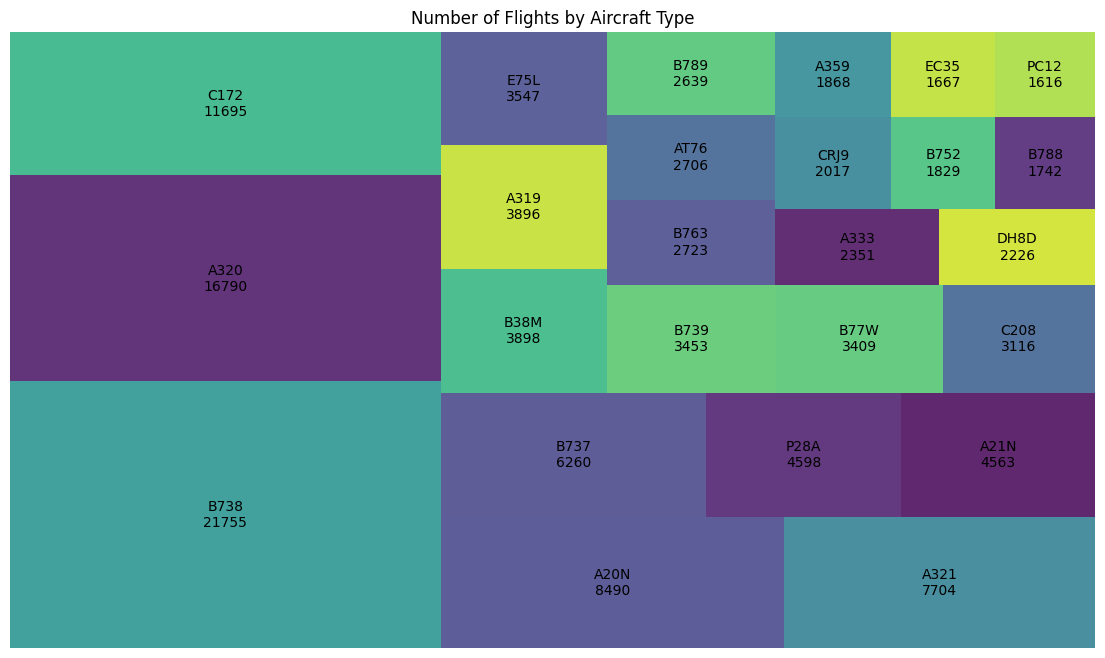

In [2]:
aircraft_types = con.execute("""
SELECT
    equipment,
    COUNT(DISTINCT flight_id) AS flights
FROM flight_events
WHERE equipment IS NOT NULL
  AND equipment <> ''
GROUP BY equipment
ORDER BY flights DESC
""").fetchdf()

top_n = 25
aircraft_types = aircraft_types.head(top_n)

labels = [
    f"{row['equipment']}\n{row['flights']}"
    for _, row in aircraft_types.iterrows()
]

plt.figure(figsize=(14, 8))
squarify.plot(
    sizes=aircraft_types["flights"],
    label=labels,
    alpha=0.85
)

plt.axis("off")
plt.title("Number of Flights by Aircraft Type")
plt.show()

### Check how much of the flights have joined successfully

In [3]:
match_check = con.execute("""
SELECT
    COUNT(*) AS total_flights,
    COUNT(*) FILTER (
        WHERE available_capacity_weight IS NOT NULL
          AND available_capacity_volume IS NOT NULL
    ) AS matched_flights,
    COUNT(*) FILTER (
        WHERE available_capacity_weight IS NULL
           OR available_capacity_volume IS NULL
    ) AS unmatched_flights
FROM flight_capacity
""").fetchdf()
match_check

,total_flights,matched_flights,unmatched_flights
0,202407,105461,96946


### Check which airplanes are not in the JSON but in the Flightdata
I see `C172` and `P28A` on the Treemap above, hmm...

In [4]:
missing_equipment = con.execute("""
SELECT
    equipment,
    COUNT(*) AS flights
FROM flight_capacity
WHERE available_capacity_weight IS NULL
   OR available_capacity_volume IS NULL
GROUP BY equipment
ORDER BY flights DESC
""").fetchdf()

total_missing = con.execute("""
SELECT COUNT(*) AS total_missing_flights
FROM flight_capacity
WHERE available_capacity_weight IS NULL
   OR available_capacity_volume IS NULL
""").fetchdf()

print(missing_equipment)
print(total_missing)

    equipment  flights
0        C172    11695
1        P28A     4598
2         NaN     3586
3        E75L     3547
4        C208     3116
..        ...      ...
628      PA20        1
629       T28        1
630      PIPA        1
631      A748        1
632      BRB2        1

[633 rows x 2 columns]
   total_missing_flights
0                  96946


Yes, we have around **3586 flights** (see above) with equipment unspecified (`NaN`). Not much we can do to infer their payload capacity unfortunately.

In [5]:
daily_capacity = con.execute("""
SELECT
    flight_date,
    origin_iata,
    destination_iata,
    SUM(available_capacity_weight) AS total_capacity_weight,
    SUM(available_capacity_volume) AS total_capacity_volume
FROM flight_capacity
GROUP BY 1, 2, 3
ORDER BY flight_date, total_capacity_weight DESC
""").fetchdf()
daily_capacity

,flight_date,origin_iata,destination_iata,total_capacity_weight,total_capacity_volume
0,2022-10-03,CJU,GMP,1.006045e+06,1030.02192
1,2022-10-03,GMP,CJU,9.851397e+05,1067.21328
2,2022-10-03,DXB,NaN,9.350680e+05,1442.29152
3,2022-10-03,ICN,NaN,9.212707e+05,1533.61920
4,2022-10-03,HND,CTS,8.122398e+05,1269.09360
...,...,...,...,...,...
113179,2022-10-09,NaN,OKC,NaN,NaN
113180,2022-10-09,SAN,VNY,NaN,NaN
113181,2022-10-09,KHH,NaN,NaN,NaN
113182,2022-10-09,JAN,TEB,NaN,NaN


### Descriptive table in the Readme:

In [6]:
con.execute("""   SELECT metric, flights, pct_of_flights                                                                                                                                                                                                   
   FROM capacity_data_quality_summary                                                                                                                                                                                                       
   ORDER BY                                                                                                                                                                                                                                 
     CASE metric                                                                                                                                                                                                                            
       WHEN 'total_flights' THEN 0                                                                                                                                                                                                          
       WHEN 'matched_full' THEN 1                                                                                                                                                                                                           
       WHEN 'matched_no_volume' THEN 2                                                                                                                                                                                                      
       WHEN 'missing_equipment' THEN 3                                                                                                                                                                                                      
       WHEN 'no_data_on_equipment' THEN 4                                                                                                                                                                                                   
       ELSE 5                                                                                                                                                                                                                               
     END; """).fetchdf()

,metric,flights,pct_of_flights
0,total_flights,202407,100.00
1,matched_full,105461,52.10
2,matched_no_volume,625,0.31
3,missing_equipment,3586,1.77
4,no_data_on_equipment,92735,45.82


### Quick integrity check to make sure I did not create duplicate rows:

In [7]:
integrity = con.execute("""                                                                                                                                                                                                              
WITH f AS (                                                                                                                                                                                                                              
    SELECT                                                                                                                                                                                                                               
        COUNT(*) AS flights_rows,                                                                                                                                                                                                        
        COUNT(DISTINCT flight_id) AS flights_distinct_flight_id                                                                                                                                                                          
    FROM flights                                                                                                                                                                                                                         
),                                                                                                                                                                                                                                       
fc AS (                                                                                                                                                                                                                                  
    SELECT                                                                                                                                                                                                                               
        COUNT(*) AS capacity_rows,                                                                                                                                                                                                       
        COUNT(DISTINCT flight_id) AS capacity_distinct_flight_id                                                                                                                                                                         
    FROM flight_capacity                                                                                                                                                                                                                 
)                                                                                                                                                                                                                                        
SELECT                                                                                                                                                                                                                                   
    f.flights_rows,                                                                                                                                                                                                                      
    f.flights_distinct_flight_id,                                                                                                                                                                                                        
    (f.flights_rows - f.flights_distinct_flight_id) AS flights_duplicate_flight_id_rows,                                                                                                                                                 
    fc.capacity_rows,                                                                                                                                                                                                                    
    fc.capacity_distinct_flight_id,                                                                                                                                                                                                      
    (fc.capacity_rows - fc.capacity_distinct_flight_id) AS capacity_duplicate_flight_id_rows,                                                                                                                                            
    (fc.capacity_rows - f.flights_rows) AS row_count_diff_capacity_minus_flights,                                                                                                                                                        
    CASE                                                                                                                                                                                                                                 
        WHEN fc.capacity_rows = f.flights_rows                                                                                                                                                                                           
        AND fc.capacity_distinct_flight_id = f.flights_distinct_flight_id                                                                                                                                                               
        THEN 'PASS'                                                                                                                                                                                                                      
        ELSE 'CHECK'                                                                                                                                                                                                                     
    END AS one_row_per_flight_check                                                                                                                                                                                                      
FROM f, fc;                                                                                                                                                                                                                              
""").df()                                                                                                                                                                                                                                
                                                                                                                                                                                                                                        
display(integrity)

,flights_rows,flights_distinct_flight_id,flights_duplicate_flight_id_rows,capacity_rows,capacity_distinct_flight_id,capacity_duplicate_flight_id_rows,row_count_diff_capacity_minus_flights,one_row_per_flight_check
0,202407,202407,0,202407,202407,0,0,PASS


### How much cargo capacity is available per day?

,flight_date,flights_in_capacity_table,flights_with_weight,flights_with_volume,total_capacity_weight_tonnes,total_capacity_volume_m3
0,2022-10-03,27928,15496,15422,426572.733504,475402.37136
1,2022-10-04,28780,14832,14725,414484.807219,481237.47504
2,2022-10-05,29252,14814,14701,416587.280735,489882.17712
3,2022-10-06,29460,14718,14620,414040.348999,486842.20752
4,2022-10-07,29532,14929,14819,417366.841024,481723.12416
5,2022-10-08,29225,15186,15115,423558.229718,487138.45248
6,2022-10-09,28230,16111,16059,449527.584087,508784.84544


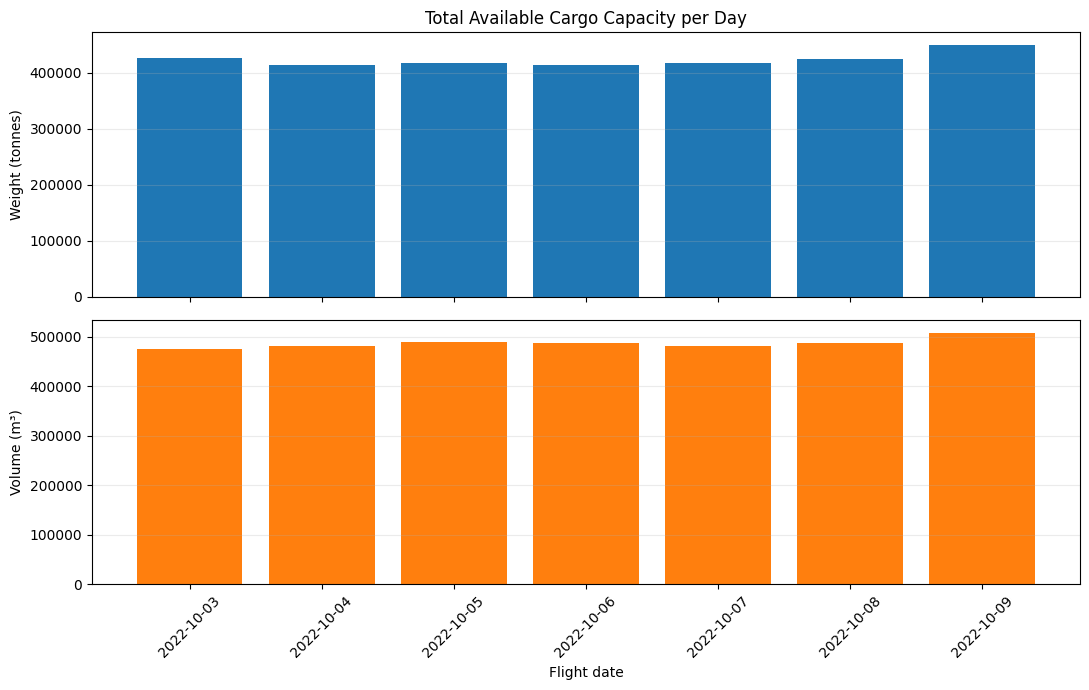

In [8]:
daily_capacity = con.execute("""                                                                                                                                                                                                         
SELECT                                                                                                                                                                                                                                   
    flight_date,                                                                                                                                                                                                                         
    COUNT(*) AS flights_in_capacity_table,                                                                                                                                                                                               
    COUNT(*) FILTER (WHERE available_capacity_weight IS NOT NULL) AS flights_with_weight,                                                                                                                                                
    COUNT(*) FILTER (WHERE available_capacity_volume IS NOT NULL) AS flights_with_volume,                                                                                                                                                
    SUM(available_capacity_weight) / 1000.0 AS total_capacity_weight_tonnes,                                                                                                                                                             
    SUM(available_capacity_volume) AS total_capacity_volume_m3                                                                                                                                                                           
FROM flight_capacity                                                                                                                                                                                                                     
GROUP BY 1                                                                                                                                                                                                                               
ORDER BY 1;                                                                                                                                                                                                                              
""").df()                                                                                                                                                                                                                                
                                                                                                                                                                                                                                        
daily_capacity["flight_date"] = pd.to_datetime(daily_capacity["flight_date"])                                                                                                                                                            
                                                                                                                                                                                                                                        
display(daily_capacity)                                                                                                                                                                                                                  
                                                                                                                                                                                                                                        
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)                                                                                                                                                                             
                                                                                                                                                                                                                                        
axes[0].bar(daily_capacity["flight_date"], daily_capacity["total_capacity_weight_tonnes"])                                                                                                                                               
axes[0].set_title("Total Available Cargo Capacity per Day")                                                                                                                                                                              
axes[0].set_ylabel("Weight (tonnes)")                                                                                                                                                                                                    
axes[0].grid(axis="y", alpha=0.25)                                                                                                                                                                                                       
                                                                                                                                                                                                                                        
axes[1].bar(daily_capacity["flight_date"], daily_capacity["total_capacity_volume_m3"], color="tab:orange")                                                                                                                               
axes[1].set_ylabel("Volume (m³)")                                                                                                                                                                                                        
axes[1].set_xlabel("Flight date")                                                                                                                                                                                                        
axes[1].grid(axis="y", alpha=0.25)                                                                                                                                                                                                       
                                                                                                                                                                                                                                        
plt.xticks(rotation=45)                                                                                                                                                                                                                  
plt.tight_layout()                                                                                                                                                                                                                       
plt.show() 

### How much of the total flights are in these charts?
Since the data is incomplete, the charts created right above do not represent the actual cargo capacities of that day, but rather the percentage of the cargo capacity that we could successfuly match on because we have the data. Below, I replicate the chart above but add data coverage percentages on top of the columns, just so we see what we are actually looking at.

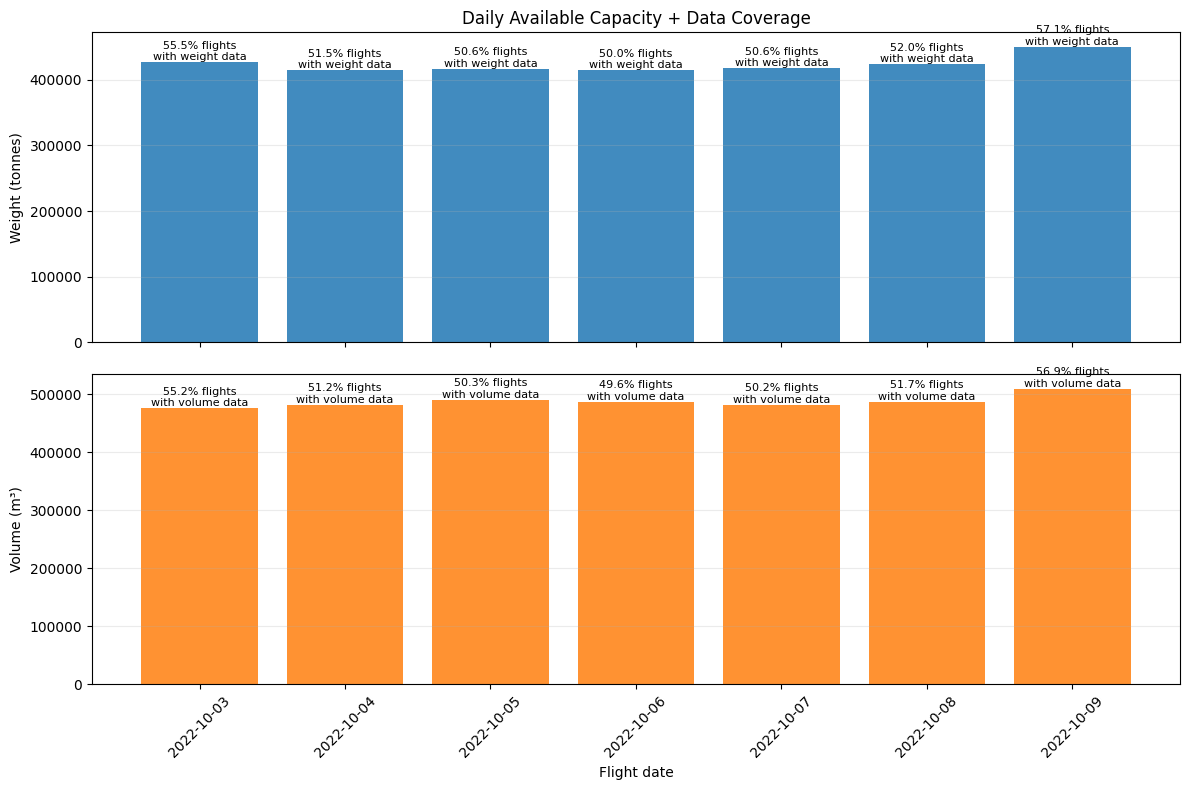

In [ ]:
import numpy as np
plot_df = daily_capacity.copy()                                                                                                                                                                                                          
plot_df["pct_with_weight"] = (                                                                                                                                                                                                           
    100.0 * plot_df["flights_with_weight"] / plot_df["flights_in_capacity_table"]                                                                                                                                                        
).round(1)                                                                                                                                                                                                                               
plot_df["pct_with_volume"] = (                                                                                                                                                                                                           
    100.0 * plot_df["flights_with_volume"] / plot_df["flights_in_capacity_table"]                                                                                                                                                        
).round(1)                                                                                                                                                                                                                               

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)                                                                                                                                                                             
                                                                                                                                                                                           
bars_w = axes[0].bar(                                                                                                                                                                                                                    
    plot_df["flight_date"],                                                                                                                                                                                                              
    plot_df["total_capacity_weight_tonnes"],                                                                                                                                                                                             
    color="tab:blue",                                                                                                                                                                                                                    
    alpha=0.85,                                                                                                                                                                                                                          
)
axes[0].set_title("Daily Available Capacity + Data Coverage")                                                                                                                                                                            
axes[0].set_ylabel("Weight (tonnes)")                                                                                                                                                                                                    
axes[0].grid(axis="y", alpha=0.25)                                                                                                                                                                                                       

for bar, pct in zip(bars_w, plot_df["pct_with_weight"]):                                                                                                                                                                                 
    h = bar.get_height()                                                                                                                                                                                                                 
    if np.isfinite(h):                                                                                                                                                                                                                   
        axes[0].text(                                                                                                                                                                                                                    
            bar.get_x() + bar.get_width() / 2,                                                                                                                                                                                           
            h,                                                                                                                                                                                                                           
            f"{pct:.1f}% flights\nwith weight data",                                                                                                                                                                                          
            ha="center",                                                                                                                                                                                                                 
            va="bottom",                                                                                                                                                                                                                 
            fontsize=8,                                                                                                                                                                                                                  
        )                                                                                                                                                                                                                                

bars_v = axes[1].bar(                                                                                                                                                                                                                    
    plot_df["flight_date"],                                                                                                                                                                                                              
    plot_df["total_capacity_volume_m3"],                                                                                                                                                                                                 
    color="tab:orange",                                                                                                                                                                                                                  
    alpha=0.85,                                                                                                                                                                                                                          
)
axes[1].set_ylabel("Volume (m³)")                                                                                                                                                                                                        
axes[1].set_xlabel("Flight date")                                                                                                                                                                                                        
axes[1].grid(axis="y", alpha=0.25)                                                                                                                                                                                                       

for bar, pct in zip(bars_v, plot_df["pct_with_volume"]):                                                                                                                                                                                 
    h = bar.get_height()                                                                                                                                                                                                                 
    if np.isfinite(h):                                                                                                                                                                                                                   
        axes[1].text(                                                                                                                                                                                                                    
            bar.get_x() + bar.get_width() / 2,                                                                                                                                                                                           
            h,                                                                                                                                                                                                                           
            f"{pct:.1f}% flights\nwith volume data",                                                                                                                                                                                          
            ha="center",                                                                                                                                                                                                                 
            va="bottom",                                                                                                                                                                                                                 
            fontsize=8,                                                                                                                                                                                                                  
        )

plt.xticks(rotation=45)                                                                                                                                                                                                                  
plt.tight_layout()                                                                                                                                                                                                                       
plt.show()    